In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [4]:
print(df.dtypes)

Дата            object
Склад            int64
Контрагент      object
Номенклатура    object
Количество       int64
dtype: object


Сразу переведем столбец "Дата" в правильный формат

In [5]:
df['Дата'] = pd.to_datetime(df['Дата'])


Сгруппируйте данные по дате, посчитайте количество продаж

In [6]:
grouped_df = df.groupby('Дата').size().reset_index(name='Количество_продаж')

Вывести несколько первых строк сгруппированных данных

In [7]:
grouped_df.head()

,Дата,Количество_продаж
0,2018-01-04,1840
1,2018-01-05,1301
2,2018-01-06,1306
3,2018-01-07,1322
4,2018-01-09,1719


Нарисуйте график продаж у `grouped_df`

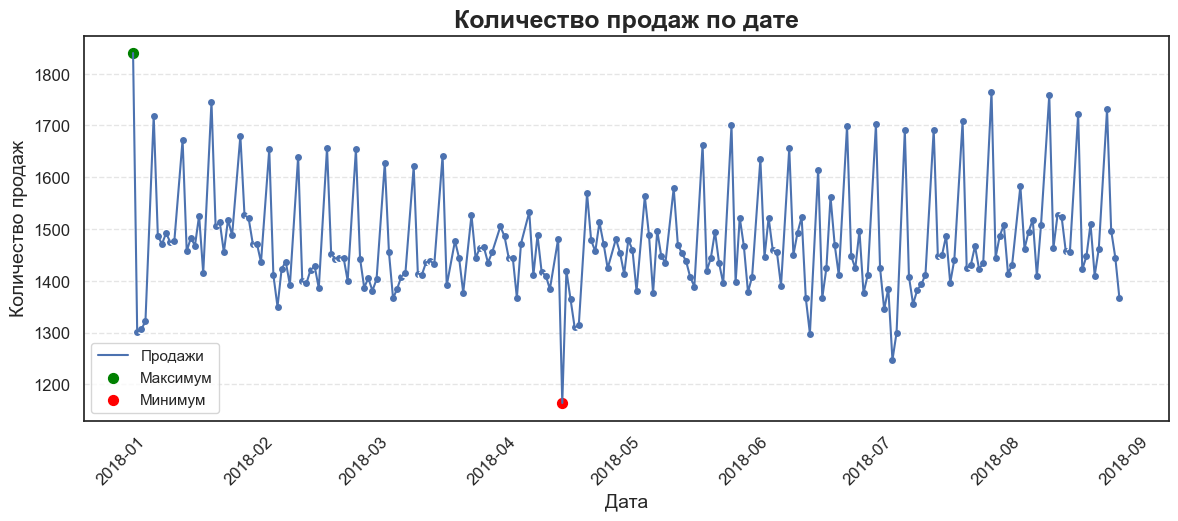

In [22]:
plt.figure(figsize=(14,5))

x = np.arange(len(grouped_df))
y = grouped_df['Количество_продаж']
plt.plot(grouped_df['Дата'], y,  linewidth=1.5, label='Продажи')
plt.scatter(grouped_df['Дата'], y, edgecolor='white')
max_idx = y.idxmax()
min_idx = y.idxmin()
plt.scatter(grouped_df['Дата'][max_idx], y[max_idx], color='green', s=50, label='Максимум')
plt.scatter(grouped_df['Дата'][min_idx], y[min_idx], color='red', s=50, label='Минимум')
plt.title('Количество продаж по дате', fontsize=18, fontweight='bold')
plt.xlabel('Дата', fontsize=14)
plt.ylabel('Количество продаж', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.legend()
plt.show() 

Опишите что вы видите на графике. Ваша задача - максимально описать график

##### Самый высокий пик — в начале января (около 1830 продаж), а самый низкий спад — в апреле (ниже 1200).
Большинство дней находятся в обычном диапазоне, на уровне 1350-1600 в день.
Резкие выбросы как в положительную, так и в отрицательную сторону, вероятно, обусловлены промо-акциями, праздничными периодами или другими нестандартными факторами, влияющими на потребительский спрос.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [9]:
Q1 = df['Количество'].quantile(0.25)
Q3 = df['Количество'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

outliers = df[df['Количество'] > upper_bound]

max_outlier = outliers.loc[outliers['Количество'].idxmax()]

print("Строка с максимальным выбросом:")
print(max_outlier)

Строка с максимальным выбросом:
Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [10]:
filtered = df[
    (df["Дата"].dt.month.isin([6, 7, 8])) &     # июнь–август
    (df["Дата"].dt.weekday == 2) &              # среда (0-Пн, 2-Ср)
    (df["Склад"] == 3)                          # склад 3
]

# Группировка по продуктам
grouped = filtered.groupby("Номенклатура", as_index=False)["Количество"].sum()

top_product = grouped.sort_values("Количество", ascending=False).head(1)

print("Топовый товар по продажам по средам (июнь–август) у склада 3:")
print(top_product)

Топовый товар по продажам по средам (июнь–август) у склада 3:
  Номенклатура  Количество
1    product_1        2267


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [11]:
#узнаем за какие даты нам нужны данные о погоде
min_date = grouped_df["Дата"].min()
max_date = grouped_df["Дата"].max()

print(min_date, max_date)

2018-01-04 00:00:00 2018-08-31 00:00:00


In [12]:
weather_df = pd.read_csv("astana_weather.csv", sep=';', encoding='utf-8',  skiprows=6, index_col=False  )
weather_df.head(2)

,Местное время в Астане,T,Po,P,Pa,U,DD,Ff,ff10,ff3,...,Cm,Ch,VV,Td,RRR,tR,E,Tg,E',sss
0,31.08.2018 23:00,8.2,736.6,768.3,0.2,78.0,"Ветер, дующий с северо-востока",4,NaN,NaN,...,"Высококучевых, высокослоистых или слоисто-дожд...","Перистых, перисто-кучевых или перисто-слоистых...",NaN,4.6,Следы осадков,12.0,NaN,NaN,NaN,NaN
1,31.08.2018 20:00,9.6,736.4,767.9,1.2,88.0,"Ветер, дующий с западо-северо-запада",3,NaN,NaN,...,"Высококучевых, высокослоистых или слоисто-дожд...","Перистых, перисто-кучевых или перисто-слоистых...",NaN,7.7,Следы осадков,12.0,NaN,NaN,NaN,NaN


In [13]:
weather_df['Дата_день'] = pd.to_datetime(weather_df['Местное время в Астане']).dt.date

C:\Users\zhunu\AppData\Local\Temp\ipykernel_14332\3497129455.py:1: UserWarning: Parsing dates in %d.%m.%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  weather_df['Дата_день'] = pd.to_datetime(weather_df['Местное время в Астане']).dt.date


In [14]:
weather_df.head(2)

,Местное время в Астане,T,Po,P,Pa,U,DD,Ff,ff10,ff3,...,Ch,VV,Td,RRR,tR,E,Tg,E',sss,Дата_день
0,31.08.2018 23:00,8.2,736.6,768.3,0.2,78.0,"Ветер, дующий с северо-востока",4,NaN,NaN,...,"Перистых, перисто-кучевых или перисто-слоистых...",NaN,4.6,Следы осадков,12.0,NaN,NaN,NaN,NaN,2018-08-31
1,31.08.2018 20:00,9.6,736.4,767.9,1.2,88.0,"Ветер, дующий с западо-северо-запада",3,NaN,NaN,...,"Перистых, перисто-кучевых или перисто-слоистых...",NaN,7.7,Следы осадков,12.0,NaN,NaN,NaN,NaN,2018-08-31


In [15]:
# Средняя температура за день
daily_temp = weather_df.groupby('Дата_день')['T'].mean().reset_index()
daily_temp.rename(columns={'T': 'T_avg'}, inplace=True)
daily_temp.head()

,Дата_день,T_avg
0,2018-01-04,-14.0750
1,2018-01-05,-16.8625
2,2018-01-06,-13.3000
3,2018-01-07,-12.7500
4,2018-01-08,-15.4125


In [16]:
daily_temp['Дата_день'] = pd.to_datetime(daily_temp['Дата_день'])
merged_df = grouped_df.merge(daily_temp, left_on='Дата', right_on='Дата_день', how='left')
merged_df.head()

,Дата,Количество_продаж,Дата_день,T_avg
0,2018-01-04,1840,2018-01-04,-14.0750
1,2018-01-05,1301,2018-01-05,-16.8625
2,2018-01-06,1306,2018-01-06,-13.3000
3,2018-01-07,1322,2018-01-07,-12.7500
4,2018-01-09,1719,2018-01-09,-6.2500


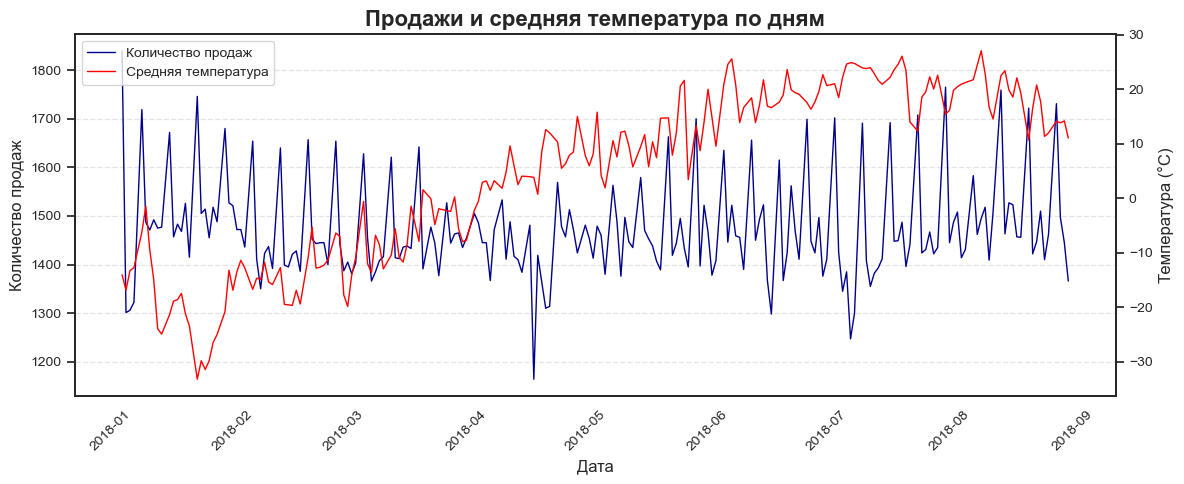

In [29]:
sns.set(style="white")  
fig, ax1 = plt.subplots(figsize=(12,5))


ax1.plot(merged_df['Дата'], merged_df['Количество_продаж'], 
         color='darkblue',  linewidth=1, label='Количество продаж', zorder=3)
ax1.set_xlabel('Дата', fontsize=12)
ax1.set_ylabel('Количество продаж', fontsize=12)
ax1.tick_params(axis='y', labelsize=10)
ax1.tick_params(axis='x', rotation=45, labelsize=10)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

ax2 = ax1.twinx()
ax2.plot(merged_df['Дата'], merged_df['T_avg'], 
         color='red', linewidth=1,label='Средняя температура', zorder=3)
ax2.set_ylabel('Температура (°C)',  fontsize=12)
ax2.tick_params(axis='y', labelsize=10)
plt.title('Продажи и средняя температура по дням', fontsize=16, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

fig.tight_layout()
plt.show()

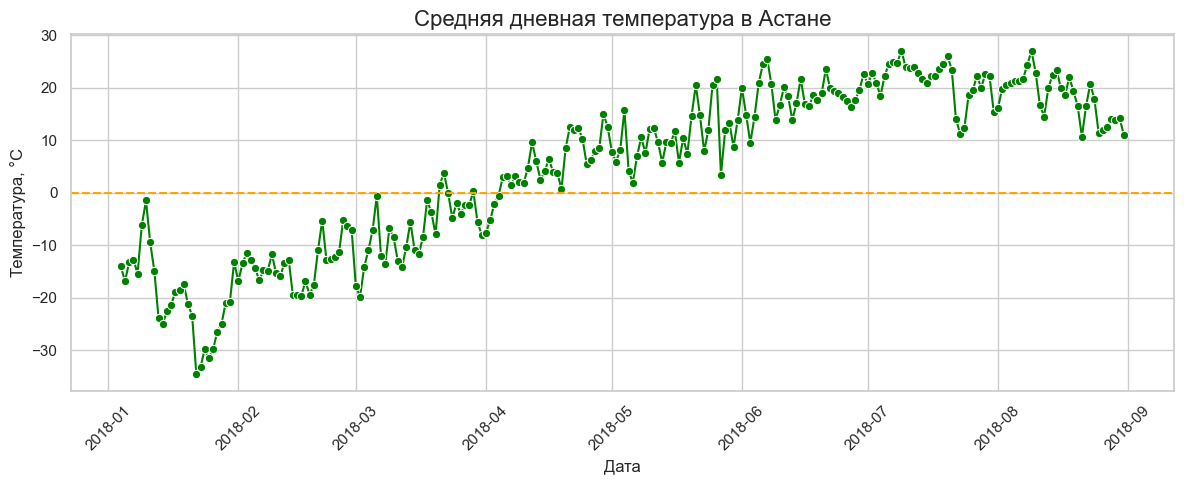

In [20]:
sns.set(style="whitegrid")
plt.figure(figsize=(12,5))
sns.lineplot(data=daily_temp, x='Дата_день', y='T_avg', marker='o', color='green')
plt.axhline(0, color='orange', linestyle='--', linewidth=1.5, label='0°C')
plt.title('Средняя дневная температура в Астане', fontsize=16)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Температура, °C', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()